In [1]:
from pyflextrkr.ftfunctions import sort_renumber, skimage_watershed
import skimage as img
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label

In [2]:
agg_version = xr.open_dataset("/wolke_scratch/dnikolo/CLAAS_Data/Resampled_Data/np/2010/01/01/Agg_03_20100101120000.nc")
filtered_version = xr.open_dataset("/wolke_scratch/dnikolo/CLAAS_Data/Filtered_Data/np/2010/01/01/Agg_03_T_30_24_20100101120000.nc")

KeyboardInterrupt: 

In [ ]:
ctx_data = xr.open_dataset("/wolke_scratch/dnikolo/CLAAS_Data/np/2010/01/01/CTXin20100101120000405SVMSG01MD.nc")

In [ ]:
config = {
    # Get thresholds from config
    'plm_min_distance': 10,
    'plm_exclude_border': 5,
    'plm_threshold_abs': 0,
    'cont_thresh': 273.15-38,
    'compa': 5,
}

In [ ]:
ctt_data = ctx_data["ctt"].values
ctt_data[(ctt_data<273.15-38) | (ctt_data>273.15)]=0
ctt_1_bin=ctt_data.copy()
ctt_1_bin[(ctt_1_bin<273.15-30) | (ctt_1_bin>273.15-24)]=0
smoothened_data = img.filters.gaussian(ctt_data[0])


In [ ]:
ctt_data_agg = agg_version["ctt_resampled"].values
ctt_data_agg[(ctt_data_agg<273.15-38) | (ctt_data_agg>273.15)]=0
ctt_1_bin_agg=ctt_data_agg.copy()
ctt_1_bin_agg[(ctt_1_bin_agg<273-30) | (ctt_1_bin_agg>273-24)]=0
smoothened_data_agg = img.filters.gaussian(ctt_data_agg[0])

In [ ]:
lab_sm_agg_all = label(smoothened_data_agg>1)

In [ ]:
lab_sm_agg_all[0].shape

(299, 1045)

In [ ]:
print(np.nanmax(ctt_data_agg),np.nanmin(ctt_data_agg[ctt_data_agg>0]) )

273.1499 235.15443


In [ ]:
ctt_data_agg.shape

(1, 299, 1045)

165.27810650887574
49006
258.67288
2297
260.97504
1
236.01575
0
nan
15
256.51376
0
nan
50
246.03217
0
nan
4
261.47742
118
260.69135
176
264.39572
331
246.37996
4839
253.9349
0
nan
6
242.90045
0
nan
9
238.4864
5
255.08585
6
255.80444
0
nan
5
235.58423
484
267.5994
6
247.9304
4
257.37152
0
nan
1
255.97906
0
nan
4
237.32812
54
265.35956
0
nan
7
244.96126
904
260.38992
0
nan
5
272.35785
4
272.33337
4
237.38309
3
239.84058
16
239.50853
10
240.97295
492
251.58746
208
251.32822
0
nan
329
250.10275
60
241.99225
0
nan
1
235.2755
483
247.34813
0
nan
1694
254.33904
6
241.79279
592
247.23206
1
235.4523
4
247.91422
1
236.56519
311
250.65982
0
nan
5
240.30322
85
254.11447
0
nan
11
242.54222
0
nan
4
237.95952
0
nan
0
nan
0
nan
23
239.38377
2
260.12915
2
245.53238
90
251.59395
152
242.63008
0
nan
0
nan
1
264.9113
43
241.71532
1864
258.31305
0
nan
0
nan
29
239.88109
0
nan
97
259.30887
0
nan
3
239.4008
39
254.58253
283
256.7843
8
246.62915
2
236.69604
113
244.64676
1
251.37773
1
249.1344
1
236.50415
0
n

/tmp/ipykernel_7388/4201511303.py:8: RuntimeWarning: Mean of empty slice
  print(np.nanmean(cloud))


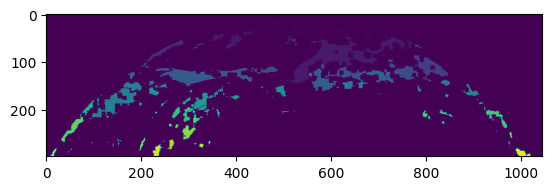

In [ ]:
plt.imshow(lab_sm_agg_all[0])
values, counts = np.unique(lab_sm_agg_all[0],return_counts=True)
print(counts[1:].mean())
for value in values:
    cloud = ctt_data_agg[0][lab_sm_agg_all[0]==value]
    cloud = cloud[cloud>0]
    print(len(cloud))
    print(np.nanmean(cloud))

In [ ]:
label((filtered_version["cph_filtered"].values[0]>0.9))

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=int32),
 2450)

In [ ]:
label((ctt_1_bin>10))

(array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]]], dtype=int32),
 12066)

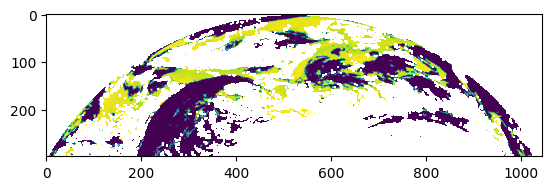

In [ ]:
plt.imshow(ctt_data[0])

In [ ]:

var_num, param_dict = skimage_watershed(smoothened_data,config)
var_num_1_bin, _ =skimage_watershed(ctt_1_bin[0],config)

1431 0


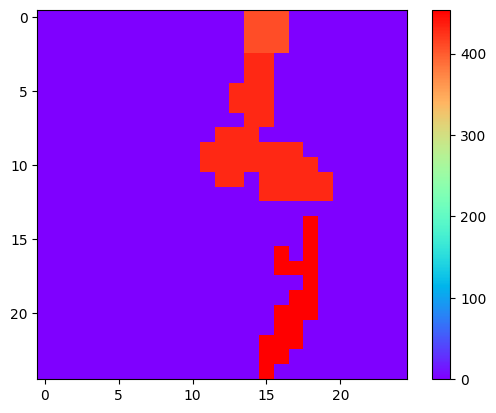

In [ ]:
print(var_num_1_bin.max(),var_num_1_bin.min())
plt.imshow(var_num_1_bin[500:525,500:525],cmap="rainbow")
plt.colorbar()

364 0


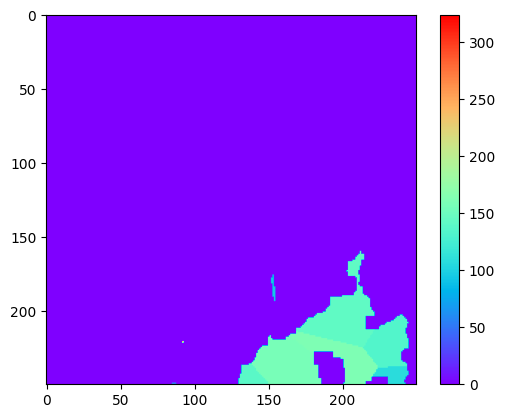

In [ ]:
print(var_num.max(),var_num.min())
plt.imshow(var_num[275:525,275:525],cmap="rainbow")
plt.colorbar()

364 0


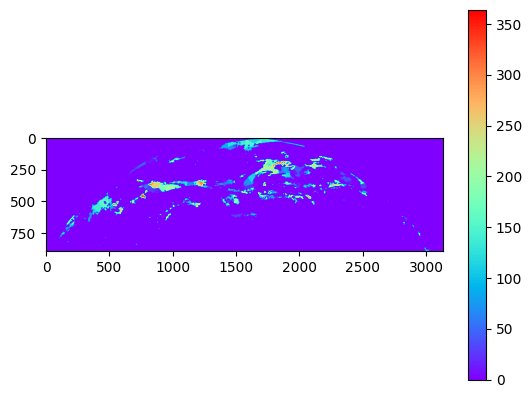

In [ ]:
print(var_num.max(),var_num.min())
plt.imshow(var_num,cmap="rainbow")
plt.colorbar()